In [1]:
import pandas as pd
import numpy as np

app = pd.read_csv("../data/raw/application_train.csv")
bureau = pd.read_csv("../data/raw/bureau.csv")
prev = pd.read_csv("../data/raw/previous_application.csv")

print(app.shape, bureau.shape, prev.shape)
bureau.head()

(307511, 122) (1716428, 17) (1670214, 37)


,SK_ID_CURR,SK_ID_BUREAU,CREDIT_ACTIVE,CREDIT_CURRENCY,DAYS_CREDIT,CREDIT_DAY_OVERDUE,DAYS_CREDIT_ENDDATE,DAYS_ENDDATE_FACT,AMT_CREDIT_MAX_OVERDUE,CNT_CREDIT_PROLONG,AMT_CREDIT_SUM,AMT_CREDIT_SUM_DEBT,AMT_CREDIT_SUM_LIMIT,AMT_CREDIT_SUM_OVERDUE,CREDIT_TYPE,DAYS_CREDIT_UPDATE,AMT_ANNUITY
0,215354,5714462,Closed,currency 1,-497,0,-153.0,-153.0,NaN,0,91323.0,0.0,NaN,0.0,Consumer credit,-131,NaN
1,215354,5714463,Active,currency 1,-208,0,1075.0,NaN,NaN,0,225000.0,171342.0,NaN,0.0,Credit card,-20,NaN
2,215354,5714464,Active,currency 1,-203,0,528.0,NaN,NaN,0,464323.5,NaN,NaN,0.0,Consumer credit,-16,NaN
3,215354,5714465,Active,currency 1,-203,0,NaN,NaN,NaN,0,90000.0,NaN,NaN,0.0,Credit card,-16,NaN
4,215354,5714466,Active,currency 1,-629,0,1197.0,NaN,77674.5,0,2700000.0,NaN,NaN,0.0,Consumer credit,-21,NaN


In [2]:
bureau_count = bureau.groupby("SK_ID_CURR").size().rename("N_BUREAU_CREDITS")
prev_count = prev.groupby("SK_ID_CURR").size().rename("N_PREV_APPS")

df = app.merge(bureau_count, on="SK_ID_CURR", how="left")
df = df.merge(prev_count, on="SK_ID_CURR", how="left")

df[["N_BUREAU_CREDITS", "N_PREV_APPS"]] = df[["N_BUREAU_CREDITS", "N_PREV_APPS"]].fillna(0)

print((df["N_BUREAU_CREDITS"] == 0).mean())
print((df["N_PREV_APPS"] == 0).mean())
print(((df["N_BUREAU_CREDITS"] == 0) & (df["N_PREV_APPS"] == 0)).mean())

0.14314935075493235
0.05350702901684818
0.008032232993291297


In [3]:
df["NO_BUREAU"] = (df["N_BUREAU_CREDITS"] == 0).astype(int)
df["NO_PREV"] = (df["N_PREV_APPS"] == 0).astype(int)
df["THIN_FILE"] = ((df["N_BUREAU_CREDITS"] <= 1) & (df["N_PREV_APPS"] <= 1)).astype(int)

print(df.groupby("NO_BUREAU")["TARGET"].agg(["mean", "count"]))
print(df.groupby("NO_PREV")["TARGET"].agg(["mean", "count"]))
print(df.groupby("THIN_FILE")["TARGET"].agg(["mean", "count"]))

               mean   count
NO_BUREAU                  
0          0.077301  263491
1          0.101249   44020
             mean   count
NO_PREV                  
0        0.081926  291057
1        0.059560   16454
               mean   count
THIN_FILE                  
0          0.079559  284543
1          0.095219   22968


C:\Users\jayra\AppData\Local\Temp\ipykernel_6996\1003978579.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["NO_BUREAU"] = (df["N_BUREAU_CREDITS"] == 0).astype(int)
C:\Users\jayra\AppData\Local\Temp\ipykernel_6996\1003978579.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["NO_PREV"] = (df["N_PREV_APPS"] == 0).astype(int)
C:\Users\jayra\AppData\Local\Temp\ipykernel_6996\1003978579.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poo

In [4]:
bureau["IS_ACTIVE"] = (bureau["CREDIT_ACTIVE"] == "Active").astype(int)

bureau_agg = bureau.groupby("SK_ID_CURR").agg(
    BUREAU_ACTIVE_COUNT=("IS_ACTIVE", "sum"),
    BUREAU_DEBT_SUM=("AMT_CREDIT_SUM_DEBT", "sum"),
    BUREAU_CREDIT_SUM=("AMT_CREDIT_SUM", "sum"),
    BUREAU_OVERDUE_MAX=("CREDIT_DAY_OVERDUE", "max"),
    BUREAU_OLDEST_CREDIT=("DAYS_CREDIT", "min"),
).reset_index()

bureau_agg.head()

,SK_ID_CURR,BUREAU_ACTIVE_COUNT,BUREAU_DEBT_SUM,BUREAU_CREDIT_SUM,BUREAU_OVERDUE_MAX,BUREAU_OLDEST_CREDIT
0,100001,3,596686.5,1453365.000,0,-1572
1,100002,2,245781.0,865055.565,0,-1437
2,100003,1,0.0,1017400.500,0,-2586
3,100004,0,0.0,189037.800,0,-1326
4,100005,2,568408.5,657126.000,0,-373


In [5]:
prev["IS_REFUSED"] = (prev["NAME_CONTRACT_STATUS"] == "Refused").astype(int)
prev["IS_APPROVED"] = (prev["NAME_CONTRACT_STATUS"] == "Approved").astype(int)

prev_agg = prev.groupby("SK_ID_CURR").agg(
    PREV_REFUSED_COUNT=("IS_REFUSED", "sum"),
    PREV_APPROVED_COUNT=("IS_APPROVED", "sum"),
    PREV_AMT_APP_MEAN=("AMT_APPLICATION", "mean"),
    PREV_AMT_CREDIT_MEAN=("AMT_CREDIT", "mean"),
).reset_index()

prev_agg.head()

,SK_ID_CURR,PREV_REFUSED_COUNT,PREV_APPROVED_COUNT,PREV_AMT_APP_MEAN,PREV_AMT_CREDIT_MEAN
0,100001,0,1,24835.50,23787.00
1,100002,0,1,179055.00,179055.00
2,100003,0,3,435436.50,484191.00
3,100004,0,1,24282.00,20106.00
4,100005,0,1,22308.75,20076.75


In [6]:
df = df.merge(bureau_agg, on="SK_ID_CURR", how="left")
df = df.merge(prev_agg, on="SK_ID_CURR", how="left")

print(df.shape)
print(df["SK_ID_CURR"].is_unique)  


(307511, 136)
True


In [7]:
print("Overall default rate:", round(df["TARGET"].mean(), 4))
print()
for t in [0, 1, 2, 3, 5]:
    mask = df["N_BUREAU_CREDITS"] <= t
    print(f"<= {t} bureau credits: {mask.sum():>6} people ({mask.mean():5.1%}), "
          f"default rate {df.loc[mask, 'TARGET'].mean():.2%}")

Overall default rate: 0.0807

<= 0 bureau credits:  44020 people (14.3%), default rate 10.12%
<= 1 bureau credits:  80092 people (26.0%), default rate 9.43%
<= 2 bureau credits: 115727 people (37.6%), default rate 8.93%
<= 3 bureau credits: 148652 people (48.3%), default rate 8.64%
<= 5 bureau credits: 202610 people (65.9%), default rate 8.28%


In [8]:
df = df.copy()

df["DAYS_EMPLOYED_ANOM"] = (df["DAYS_EMPLOYED"] == 365243).astype(int)
df["DAYS_EMPLOYED"] = df["DAYS_EMPLOYED"].replace(365243, np.nan)

df["CREDIT_INCOME_RATIO"] = df["AMT_CREDIT"] / df["AMT_INCOME_TOTAL"]
df["ANNUITY_INCOME_RATIO"] = df["AMT_ANNUITY"] / df["AMT_INCOME_TOTAL"]
df["CREDIT_TERM"] = df["AMT_ANNUITY"] / df["AMT_CREDIT"]

ext = ["EXT_SOURCE_1", "EXT_SOURCE_2", "EXT_SOURCE_3"]
df["EXT_SOURCE_MEAN"] = df[ext].mean(axis=1)
df["EXT_MISSING_COUNT"] = df[ext].isnull().sum(axis=1)

df["THIN_FILE"] = (df["N_BUREAU_CREDITS"] <= 1).astype(int)

print(df.shape)

(307511, 142)


In [9]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, average_precision_score
import lightgbm as lgb

y = df["TARGET"]
X_all = df.drop(columns=["TARGET", "SK_ID_CURR"])

cat_cols = [c for c in X_all.columns if not pd.api.types.is_numeric_dtype(X_all[c])]
for c in cat_cols:
    X_all[c] = X_all[c].astype("category")

new_cols = [
    "N_BUREAU_CREDITS", "N_PREV_APPS", "NO_BUREAU", "NO_PREV", "THIN_FILE",
    "BUREAU_ACTIVE_COUNT", "BUREAU_DEBT_SUM", "BUREAU_CREDIT_SUM",
    "BUREAU_OVERDUE_MAX", "BUREAU_OLDEST_CREDIT",
    "PREV_REFUSED_COUNT", "PREV_APPROVED_COUNT",
    "PREV_AMT_APP_MEAN", "PREV_AMT_CREDIT_MEAN",
    "CREDIT_INCOME_RATIO", "ANNUITY_INCOME_RATIO", "CREDIT_TERM",
    "EXT_SOURCE_MEAN", "EXT_MISSING_COUNT",
]
X_base = X_all.drop(columns=new_cols)

def run(X, name):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, stratify=y, random_state=42
    )
    model = lgb.LGBMClassifier(n_estimators=300, learning_rate=0.05,
                               random_state=42, verbose=-1)
    model.fit(X_train, y_train)
    probs = model.predict_proba(X_test)[:, 1]
    print(f"{name:<22} ROC-AUC: {roc_auc_score(y_test, probs):.4f}   "
          f"PR-AUC: {average_precision_score(y_test, probs):.4f}   "
          f"({X.shape[1]} features)")
    return model, X_test, y_test, probs

model_base, *_ = run(X_base, "Baseline (old cols)")
model_full, X_test, y_test, probs_full = run(X_all, "Full (new features)")

Baseline (old cols)    ROC-AUC: 0.7596   PR-AUC: 0.2507   (121 features)
Full (new features)    ROC-AUC: 0.7715   PR-AUC: 0.2646   (140 features)


In [10]:
imp = pd.Series(model_full.feature_importances_, index=X_all.columns).sort_values(ascending=False)
print(imp.head(15))

ORGANIZATION_TYPE       999
CREDIT_TERM             594
EXT_SOURCE_3            321
EXT_SOURCE_MEAN         310
DAYS_BIRTH              300
DAYS_EMPLOYED           288
EXT_SOURCE_1            275
BUREAU_CREDIT_SUM       247
BUREAU_DEBT_SUM         243
BUREAU_OLDEST_CREDIT    231
EXT_SOURCE_2            230
DAYS_ID_PUBLISH         225
PREV_AMT_CREDIT_MEAN    224
AMT_ANNUITY             209
PREV_AMT_APP_MEAN       184
dtype: int32


In [11]:
test = pd.DataFrame({
    "y": y_test.values,
    "risk": probs_full,
    "thin": df.loc[X_test.index, "THIN_FILE"].values,
})

for flag, name in [(0, "Not thin-file"), (1, "Thin-file")]:
    g = test[test["thin"] == flag]
    print(f"{name:<14} people: {len(g):>6} | actual default rate: {g['y'].mean():.2%} | "
          f"avg predicted risk: {g['risk'].mean():.2%} | "
          f"ROC-AUC: {roc_auc_score(g['y'], g['risk']):.4f} | "
          f"PR-AUC: {average_precision_score(g['y'], g['risk']):.4f}")

Not thin-file  people:  45428 | actual default rate: 7.54% | avg predicted risk: 7.55% | ROC-AUC: 0.7755 | PR-AUC: 0.2569
Thin-file      people:  16075 | actual default rate: 9.59% | avg predicted risk: 9.37% | ROC-AUC: 0.7559 | PR-AUC: 0.2824


d:\Project\Credit_Risk_Pipeline\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
d:\Project\Credit_Risk_Pipeline\.venv\Lib\site-packages\shap\explainers\_tree.py:632: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


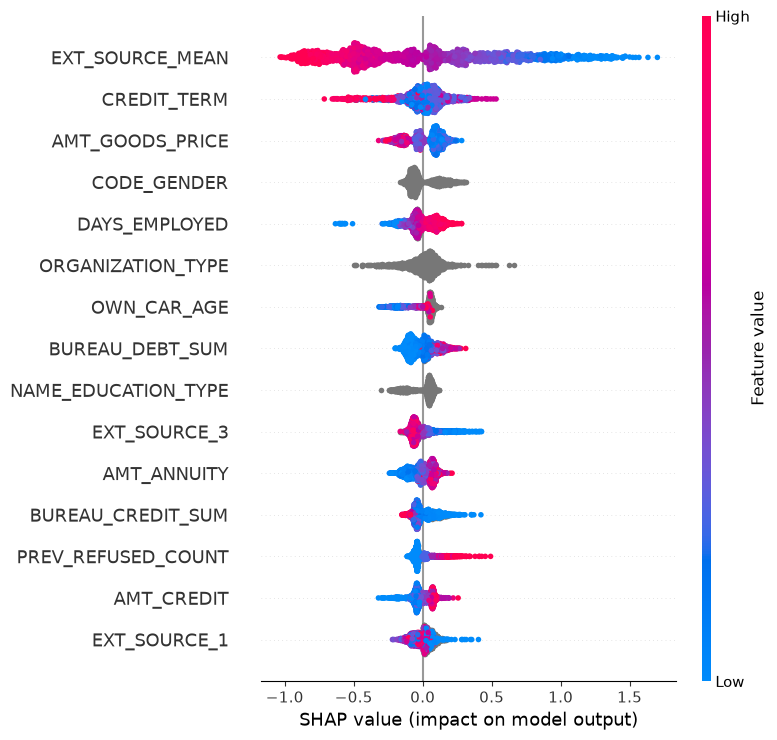

In [12]:
import shap

X_sample = X_test.sample(2000, random_state=42)

explainer = shap.TreeExplainer(model_full)
sv = explainer.shap_values(X_sample)

if isinstance(sv, list):          # some versions return one array per class
    sv = sv[1]
if getattr(sv, "ndim", 2) == 3:   # others return a 3D array
    sv = sv[:, :, 1]

shap.summary_plot(sv, X_sample, max_display=15)

In [13]:
print("Mean |SHAP| of key features:")
for col in ["THIN_FILE", "N_BUREAU_CREDITS", "EXT_MISSING_COUNT", "EXT_SOURCE_MEAN", "CREDIT_TERM"]:
    i = list(X_sample.columns).index(col)
    print(f"{col:<20} {np.abs(sv[:, i]).mean():.4f}")

Mean |SHAP| of key features:
THIN_FILE            0.0000
N_BUREAU_CREDITS     0.0124
EXT_MISSING_COUNT    0.0164
EXT_SOURCE_MEAN      0.5082
CREDIT_TERM          0.1205


In [14]:
X_nogender = X_all.drop(columns=["CODE_GENDER"])
model_ng, X_test_ng, y_test_ng, probs_ng = run(X_nogender, "Without gender")

Without gender         ROC-AUC: 0.7700   PR-AUC: 0.2642   (139 features)


In [15]:
audit = pd.DataFrame({
    "y": y_test_ng.values,
    "risk": probs_ng,
    "gender": df.loc[X_test_ng.index, "CODE_GENDER"].values,
    "age": (-df.loc[X_test_ng.index, "DAYS_BIRTH"] / 365).values,
    "thin": df.loc[X_test_ng.index, "THIN_FILE"].values,
})
audit["age_band"] = pd.cut(audit["age"], [0, 30, 40, 50, 60, 100],
                           labels=["<30", "30-39", "40-49", "50-59", "60+"])

cutoff = audit["risk"].quantile(0.80)            # reject the riskiest 20%
audit["rejected"] = (audit["risk"] >= cutoff).astype(int)

def report(col):
    rows = []
    for name, g in audit.groupby(col, observed=True):
        good = g[g["y"] == 0]
        rows.append({
            col: name,
            "people": len(g),
            "actual_default_%": round(g["y"].mean() * 100, 2),
            "avg_predicted_%": round(g["risk"].mean() * 100, 2),
            "rejected_%": round(g["rejected"].mean() * 100, 1),
            "good_wrongly_rejected_%": round(good["rejected"].mean() * 100, 1),
        })
    return pd.DataFrame(rows)

for c in ["gender", "age_band", "thin"]:
    print(report(c), "\n")

  gender  people  actual_default_%  avg_predicted_%  rejected_%  \
0      F   40561              6.99             7.35        17.0   
1      M   20940             10.17             9.37        25.7   
2    XNA       2              0.00             9.24         0.0   

   good_wrongly_rejected_%  
0                     14.6  
1                     21.8  
2                      0.0   

  age_band  people  actual_default_%  avg_predicted_%  rejected_%  \
0      <30    8866             11.30            11.60        35.6   
1    30-39   16490              9.58             9.39        25.4   
2    40-49   15282              7.57             7.61        17.9   
3    50-59   13610              6.37             6.28        12.7   
4      60+    7255              4.96             4.79         6.8   

   good_wrongly_rejected_%  
0                     31.4  
1                     21.6  
2                     15.1  
3                     10.7  
4                      5.8   

   thin  people  actua

In [16]:
pd.set_option("display.width", 200)

def audit_report(probs, test_index, y_true, title):
    a = pd.DataFrame({
        "y": np.asarray(y_true),
        "risk": probs,
        "gender": df.loc[test_index, "CODE_GENDER"].values,
        "age_band": pd.cut(-df.loc[test_index, "DAYS_BIRTH"].values / 365,
                           [0, 30, 40, 50, 60, 100],
                           labels=["<30", "30-39", "40-49", "50-59", "60+"]),
        "thin": df.loc[test_index, "THIN_FILE"].values,
    })
    a["rejected"] = (a["risk"] >= a["risk"].quantile(0.80)).astype(int)
    print("=====", title, "=====")
    for col in ["gender", "age_band", "thin"]:
        rows = []
        for name, g in a.groupby(col, observed=True):
            if len(g) < 100:
                continue
            rows.append({col: name, "n": len(g),
                         "actual%": round(g["y"].mean() * 100, 2),
                         "pred%": round(g["risk"].mean() * 100, 2),
                         "rejected%": round(g["rejected"].mean() * 100, 1),
                         "good_rejected%": round(g.loc[g["y"] == 0, "rejected"].mean() * 100, 1)})
        print(pd.DataFrame(rows).to_string(index=False), "\n")

audit_report(probs_ng, X_test_ng.index, y_test_ng, "Without gender")

===== Without gender =====
gender     n  actual%  pred%  rejected%  good_rejected%
     F 40561     6.99   7.35       17.0            14.6
     M 20940    10.17   9.37       25.7            21.8 

age_band     n  actual%  pred%  rejected%  good_rejected%
     <30  8866    11.30  11.60       35.6            31.4
   30-39 16490     9.58   9.39       25.4            21.6
   40-49 15282     7.57   7.61       17.9            15.1
   50-59 13610     6.37   6.28       12.7            10.7
     60+  7255     4.96   4.79        6.8             5.8 

 thin     n  actual%  pred%  rejected%  good_rejected%
    0 45428     7.54   7.56       18.1            15.3
    1 16075     9.59   9.39       25.3            21.8 



In [17]:
tmp = df.loc[X_test_ng.index]
bands = pd.cut(-tmp["DAYS_BIRTH"] / 365, [0, 30, 40, 50, 60, 100],
               labels=["<30", "30-39", "40-49", "50-59", "60+"])
print(tmp.groupby(bands, observed=True)["THIN_FILE"].mean().round(3))

DAYS_BIRTH
<30      0.360
30-39    0.245
40-49    0.237
50-59    0.241
60+      0.269
Name: THIN_FILE, dtype: float64


In [18]:
X_noage = X_nogender.drop(columns=["DAYS_BIRTH"])
model_na, X_test_na, y_test_na, probs_na = run(X_noage, "Without gender and age")
audit_report(probs_na, X_test_na.index, y_test_na, "Without gender and age")

Without gender and age ROC-AUC: 0.7687   PR-AUC: 0.2623   (138 features)
===== Without gender and age =====
gender     n  actual%  pred%  rejected%  good_rejected%
     F 40561     6.99   7.34       17.1            14.6
     M 20940    10.17   9.35       25.7            21.8 

age_band     n  actual%  pred%  rejected%  good_rejected%
     <30  8866    11.30  12.36       38.7            34.6
   30-39 16490     9.58   9.03       24.2            20.4
   40-49 15282     7.57   7.42       17.1            14.4
   50-59 13610     6.37   6.36       13.0            11.1
     60+  7255     4.96   4.84        6.7             5.7 

 thin     n  actual%  pred%  rejected%  good_rejected%
    0 45428     7.54   7.55       18.2            15.3
    1 16075     9.59   9.37       25.2            21.8 



In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_validate

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

configs = {
    "current": dict(n_estimators=300, learning_rate=0.05),
    "tuned-1": dict(n_estimators=600, learning_rate=0.03, colsample_bytree=0.5,
                    subsample=0.8, subsample_freq=1, min_child_samples=50),
}

for name, params in configs.items():
    m = lgb.LGBMClassifier(random_state=42, verbose=-1, **params) # type: ignore
    res = cross_validate(m, X_nogender, y, cv=cv,
                         scoring=["roc_auc", "average_precision"], n_jobs=1)
    print(f"{name:<8} ROC-AUC {res['test_roc_auc'].mean():.4f} ± {res['test_roc_auc'].std():.4f} | "
          f"PR-AUC {res['test_average_precision'].mean():.4f} ± {res['test_average_precision'].std():.4f}")

current  ROC-AUC 0.7676 ± 0.0045 | PR-AUC 0.2547 ± 0.0065
tuned-1  ROC-AUC 0.7707 ± 0.0042 | PR-AUC 0.2596 ± 0.0065
